In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

load_dotenv()

# 모델 초기화
model = ChatGoogleGenerativeAI(
    model=os.getenv("GEMINI_MODEL", "gemini-2.0-flash"),
    google_api_key=os.getenv("GEMINI_API_FREE_KEY") or os.getenv("GEMINI_API_KEY"),
    temperature=0.01
)

model.invoke('안녕하세요!')

AIMessage(content=[{'type': 'text', 'text': '안녕하세요! 반갑습니다. 무엇을 도와드릴까요? 궁금한 점이 있거나 도움이 필요하시면 언제든 말씀해 주세요.', 'extras': {'signature': 'EsoHCscHAb4+9vuM7vJ12M/3/7UH9CPyJ8UOswkvbv6ruvQ2seGgtCRQn6DCwyai7nBKjCAbK7bvT/vpDCycQcyXqQ5EPkvIU+m3SwAhAHX+ltB/L/05VphTVVKjt0evpx/hAgBNsjnMKPIhxDC/6UtLMWVtKozTHVjkByxT9aJhI40i7/JODl2q/CnkuTHgZggpJ/Yhy8E0KJTgUsAY/k4V8sYX0M4A/sfgsUUajiy1i8RwLeh+wpUX0v/ErhJ/rAFZBelTUyl1wbqpWWTvAyx+LVbtKNEcji3VHxO/iY2TjYAOcokZORGA/SLeVlX28q2xtQb8kfhbjylsOBTxH7EXE3iTw+8TZ/ER3dX+wzGh39Avuk5JV+tmSZJzKukz/Juq8IZ4L27CnVYUVzdQt+hMZpBThHQuY0mf3VfP8gwaJJaqse2bK46e1eauPM4KFgd8xt7MfB3SoglVglAqY6WsxtNjntFwcGRFLYTU5+B0ESMKulIEGZNUHYsuiNZWdFgEq6JLOtwRrHP4GyC7HU/i85x3z1oCsLnCu8sTQ2CX8izqOZgLeSphAgcPV/OptLXPWg8nDF9tJpv5a/bclUbRk0fHItJyikSDodSiqHVKtkjaK/cWdpou9esdq1N4qF+w7XXDcZrgf8To/U7P16oyN6whg8ZY+KzJ5AZ3S6ayskZ/xB5oD29fbPOOfPgyxntQTUahqw6usOC6uAiBYCp/Jj7wIVqZYjAx/KGRuwyIGsQfIRCaEj9TPPo/qbG2ZLLmOmz8+7vldBd+wx+J2EULpi8JBjBlTdzLkwn1GEMLFs5tbVIAVkxLJ66Rm3QXzDICGgFPS8D4TgcirErJnQqJnPILO9mFkcjx

In [2]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다. 
        주석에 있는 'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State) 

In [3]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_tavily import TavilySearch

# 도구 함수 정의
@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재시각 {now}'
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"

@tool
def get_web_search(query: str) -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색어

    Returns:
        str: 검색 결과
    """
    print('\n-------- WEB SEARCH --------')
    print(query)

    search = TavilySearch(max_results=5)
    result = search.invoke({"query": query})

    for i, r in enumerate(result.get("results", [])):
        print(f'{i+1}. {r["title"]} - {r["url"]}')

    return str(result)

# 도구 바인딩
tools = [get_current_time, get_web_search]

In [4]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "서울"})

'Asia/Seoul (서울) 현재시각 2026-03-25 12:59:27'

In [5]:
tools[1].invoke({"query": "파이썬"})


-------- WEB SEARCH --------
파이썬
1. 파이썬 - 위키백과, 우리 모두의 백과사전 - https://ko.wikipedia.org/wiki/%ED%8C%8C%EC%9D%B4%EC%8D%AC
2. Python - 나무위키:대문 - https://namu.wiki/w/Python
3. Python란 무엇인가요? - Python 언어 설명 - AWS - https://aws.amazon.com/ko/what-is/python/
4. Welcome to Python.org - https://www.python.org/
5. 파이썬 코딩 무료 강의 (기본편) - 6시간 뒤면 여러분도 개발자가 될 수 ... - https://www.youtube.com/watch?v=kWiCuklohdY


'{\'query\': \'파이썬\', \'follow_up_questions\': None, \'answer\': None, \'images\': [], \'results\': [{\'url\': \'https://ko.wikipedia.org/wiki/%ED%8C%8C%EC%9D%B4%EC%8D%AC\', \'title\': \'파이썬 - 위키백과, 우리 모두의 백과사전\', \'content\': \'파이썬은 비영리 파이썬 소프트웨어 재단이 관리하는 개방형, 공동체 기반 개발 모델이 있다. 목차. 1 개요; 2 역사. 2.1 파이썬 2; 2.2 파이썬 3; 2.3\', \'score\': 0.8055255, \'raw_content\': None}, {\'url\': \'https://namu.wiki/w/Python\', \'title\': \'Python - 나무위키:대문\', \'content\': \'예를 들어 C++로 구현되어 있지만 파이썬에서 사용할 수 있는 OpenCV, C와 C++로 구현된 NumPy 등, 다른 언어로 구현된 후 파이썬으로 사용할 수 있도록 만들어진 라이브러리는 파이썬 생태계에서 중요한 축을 담당한다. 겉보기에는 큰 문제처럼 보이지만 생각보다 큰 문제가 되지 않는데 파이썬의 직관적인 문법 덕분에 개발 속도가 매우 크게 단축이 되고 NumPy는 C "C(프로그래밍 언어)"), TensorFlow나 PyTorch는 C++로, Polars는 Rust같이 더 빠른 언어로 만든 후 래핑하여 파이썬에 사용하는 라이브러리들의 경우 순수 파이썬 구현이 아니기 때문에 빠른 언어와 비교 시 실행 속도에 별다른 영향을 미치지 못한다. setup.py를 실행하는 데 필요한 도구가 있는지 확인하고, 없으면 자동으로 설치하거나 사용자에게 알려주는 기능이 없으며 임의의 파이썬 코드이기에 작성하기 때문에 패키지 이름이나 버전과 같은 메타데이터를 추출하는 것이 까다로우며 악의적인 코드를 심을 수 있고, setuptools를 직접 import하기 때문에 사

In [6]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x0000020658404EA0>
get_web_search name='get_web_search' description='웹 검색을 수행하는 함수.\n\nArgs:\n    query (str): 검색어\n\nReturns:\n    str: 검색 결과' args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x00000206572DE200>


In [7]:
model_with_tools = model.bind_tools(tools) # GPT 언어모델에 도구 연결

def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.

    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}입니다.
    """
    return {"messages": model_with_tools.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [8]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    Attributes:
        tools_by_name (dict): 도구 이름을 키로 하고 도구 객체를 값으로 가지는 사전입니다.
    Methods:
        __init__(tools: list): 도구 객체들의 리스트를 받아서 초기화합니다.
        __call__(inputs: dict): 입력 메시지를 받아서 도구를 실행하고 결과 메시지를 반환합니다.
    """
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:    # ①
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):    # ②
        if messages := inputs.get("messages", []):
            # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트를 가져옵니다.
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:    # ③
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}

tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [9]:
def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 끝으로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아갑니다.
graph_builder.add_edge("tools", "generate")
graph = graph_builder.compile()


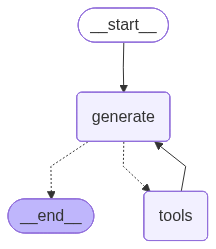

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 서울 몇시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        content = msg.content
        if isinstance(content, list) and len(content) > 0:
            content = content[0].get("text", "")
        if content:
            print(content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

gathered

현재 서울 시간은 2026년 3월 25일 오후 12시 59분입니다.

AIMessageChunk(content=[{'type': 'text', 'text': '현재 서울 시간은 2026년 3월 25일 오후 12시 59분입니다.', 'index': 0, 'extras': {'signature': 'Et0BCtoBAb4+9vs8mBLRRPivzYBSdCvMylVC4N7DHEedPmkAQiZU0yvPSkN9bwqYaLW+Qwi/xAv4RZkH4uCaxyz5JJA5Rkkgw7eDYtg6KJ4tuaFszjCy1dSQRHMq7SeoMsrkBaL/evsig60nFdOymKZiZMnMUeJaBvGSZOm6+bHEJn4bQEPj7/K1BsejD7gpmulByZ3AjRnWIzMFU5buG7yTceiXG5v6KHHfCHMe9wGVoZjdSFBt6YVGcfvH19qX6G3kJn/QfOsjOvm0GP8h5eSkbazsG/PDXiXA/b0U7BY='}}], additional_kwargs={'function_call': {'name': 'get_current_time', 'arguments': '{"location": "Seoul", "timezone": "Asia/Seoul"}'}, '__gemini_function_call_thought_signatures__': {'517502ee-094c-40e5-8b82-c16da514233c': 'Er4DCrsDAb4+9vsU/f1ZlCf7VKpr+FeE90tG7Sb7uvUv5RhTIwQ39K/LczcTvJAbb/okY76E+FTdcjr5ClDBIfPBTdGiWicJvAfY4gbY7VUemIb/6L17pl/mW4nPbco2PgmTeNb12D4/lNipvsdRJPNIuPS1RXmK8rush66czcZL3OG36NwxK/mnZkSIMov1N+D/IciIVX4t5fCpLA/PCnQ1s59RwWQwTu5g1GrGOjTtL7ticUr2hVtZgeE3CSWtmVXGJLwMuxWtIMniB4YvdePJpmV57erJVdCEE+40EVtk2vk5O1tP+BIZofIqaJLbTdSskiuSxEMA+jupAD7Tvrnt0gp/

In [14]:
from langchain_core.messages import AIMessageChunk, SystemMessage, HumanMessage

about = "서울월드컵 경기장 잔디 문제"

inputs = [
    SystemMessage(content=f"""
너는 신문기자이다. 
최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.  

- 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘. 
- 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐. 
- 검색할 리스트를 토대로 재검색을 한다. 
- 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해라.
- 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋다. 

더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성하라.
제목, 부제, 리드문, 본문 의 구성으로 작성하라. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다. 
그리고 markdown 형식으로 작성하라.
    """),
    HumanMessage(content="기사를 작성해줘.")  # ← Gemini를 위해 추가
]

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        content = msg.content
        if isinstance(content, list) and len(content) > 0:
            content = content[0].get("text", "")
        if content:
            print(content, end='')


-------- WEB SEARCH --------
서울월드컵경기장 잔디 문제 최근 이슈 손흥민 비판 이라크전 용인 이전
1. [오피셜] "잔디 좀 개선됐으면…" 손흥민 작심발언, 10월 이라크전 상암 ... - https://v.daum.net/v/20240924183115028?f=p
2. 손흥민도 지적했던 상암 잔디, 결국…이라크전 용인 간다 / JTBC 뉴스룸 - https://www.youtube.com/watch?v=YrmucrewG_I
3. 손흥민도 지적한 상암경기장…행사로 82억 벌고 잔디엔 2.5억 썼다 - https://v.daum.net/v/zjN8NwkPSj
4. 손흥민 지적에 A매치 장소 변경, 잔디 해결했더니 교통이 문제 - 스포츠 - https://sports.news.nate.com/view/20240926n26637
5. '최악' 상암 잔디에…이라크전 장소 바뀔 수도 (자막뉴스) / SBS - https://www.youtube.com/watch?v=0W_fUUUkVkU

-------- WEB SEARCH --------
서울시설공단 서울월드컵경기장 수익 잔디 관리 예산 내역
1. 82억 번 서울월드컵경기장, 잔디 관리에는 2.5억 썼다 - 중앙일보 - https://www.joongang.co.kr/article/25280102
2. 서울월드컵경기장, 110억 벌고 잔디 관리엔 2억4000만 원 - Dailymotion - https://www.dailymotion.com/video/x9687t8
3. 서울월드컵경기장, 110억 벌고 잔디 관리엔 2억4000만 원 - 채널A - https://ichannela.com/news/detail/000000434802.do
4. 3년에 190억원 벌었으면서 잔디엔 7억원 썼다 - 조선일보 - https://www.chosun.com/sports/football/2024/09/26/2UMUVW5SXRGLJPUKAFBZTEONJI/
5. 82억 번 월드컵경기장...잔디관리엔 '이만큼' 